In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Cau hinh phong cach bieu do
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11, 'figure.facecolor': 'white'})

print("Dang xu ly sieu ma tran du lieu...")
df_raw = pd.read_excel('data.xlsx', sheet_name='Data')

# Lam sach va Melt
year_cols = [col for col in df_raw.columns if '[YR' in str(col)]
rename_dict = {col: int(str(col).split(' ')[0]) for col in year_cols}
df_raw.rename(columns=rename_dict, inplace=True)
df_raw.replace('..', np.nan, inplace=True)

df_melted = pd.melt(df_raw, id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
                    value_vars=list(rename_dict.values()), var_name='Year', value_name='Value')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

target_countries = [
    'Viet Nam', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines', 'Brunei Darussalam', 'Cambodia', 'Lao PDR',
    'Myanmar', 'Timor-Leste',
    'Singapore',
    'High income', 'Middle income', 'Low income'
]
df_clean = df_melted[df_melted['Country Name'].isin(target_countries)].copy()
df_multi = df_clean.pivot_table(index=['Country Name', 'Year'], columns='Series Code', values='Value').reset_index()

indicators = {
    'TX.VAL.TECH.MF.ZS': 'HighTech_Export', 'GB.XPD.RSDV.GD.ZS': 'RnD',
    'IP.PAT.RESD': 'Patent_Resident', 'IP.PAT.NRES': 'Patent_NonResident',
    'BX.KLT.DINV.WD.GD.ZS': 'FDI_Inflows', 'HD_HCIP_OVRL_TO': 'HCI',
    'SL.EMP.WORK.ZS': 'Wage_Jobs', 'SL.GDP.PCAP.EM.KD': 'Productivity',
    'SM.POP.NETM': 'Net_Migration', 'BX.TRF.PWKR.DT.GD.ZS': 'Remittances',
    'CC.EST': 'WGI_CC', 'GE.EST': 'WGI_GE', 'VA.EST': 'WGI_VA',
    'RQ.EST': 'WGI_RQ', 'RL.EST': 'WGI_RL', 'PV.EST': 'WGI_PV',
    'NV.MNF.TECH.ZS.UN': 'Tech_ValueAdded'
}
df_multi.rename(columns=indicators, inplace=True)

# Noi suy theo thoi gian trong tung quoc gia (chi cho cac cot so)
df_multi = df_multi.sort_values(['Country Name', 'Year']).reset_index(drop=True)
value_cols = [c for c in df_multi.columns if c not in ['Country Name', 'Year']]

missing_before = int(df_multi[value_cols].isna().sum().sum())
df_multi[value_cols] = df_multi.groupby('Country Name')[value_cols].transform(
    lambda s: s.interpolate(method='linear', limit_direction='both')
)
missing_after = int(df_multi[value_cols].isna().sum().sum())

print(f'Missing truoc noi suy: {missing_before}')
print(f'Missing sau noi suy: {missing_after}')
print("San sang phan tich Cum A, B, C!")

Dang xu ly sieu ma tran du lieu...
Missing truoc noi suy: 1869
Missing sau noi suy: 875
San sang phan tich Cum A, B, C!


In [2]:
# ===================== CHECK MISSING VALUES =====================
print('===== KIEM TRA MISSING TREN df_multi =====')

# 1) Tong quan
n_rows, n_cols = df_multi.shape
total_missing = int(df_multi.isna().sum().sum())
print(f'So dong: {n_rows}, so cot: {n_cols}')
print(f'Tong so gia tri missing: {total_missing}')

# 2) Missing theo cot
missing_by_col = df_multi.isna().sum().sort_values(ascending=False)
missing_by_col = missing_by_col[missing_by_col > 0]

if missing_by_col.empty:
    print('Khong co cot nao bi missing.')
else:
    print('\nSo luong missing theo cot:')
    print(missing_by_col)

# 3) Missing o dong nao + cot nao
miss_locs = (
    df_multi.isna()
    .stack()
    .loc[lambda s: s]
    .rename('is_missing')
    .reset_index()
)

# Dat ten row index on dinh
if 'level_0' in miss_locs.columns:
    miss_locs = miss_locs.rename(columns={'level_0': 'row_idx'})

# Xac dinh cot chua ten bien bi missing (co the la level_1 hoac ten cot goc, vd: Series Code)
meta_like = {'row_idx', 'Country Name', 'Year', 'is_missing'}
missing_col_candidates = [c for c in miss_locs.columns if c not in meta_like]

if missing_col_candidates:
    miss_locs = miss_locs.rename(columns={missing_col_candidates[0]: 'missing_column'})
else:
    miss_locs['missing_column'] = np.nan

# Loai bo cot bool trung gian
if 'is_missing' in miss_locs.columns:
    miss_locs = miss_locs.drop(columns=['is_missing'])

if miss_locs.empty:
    print('\nKhong co missing o cap do o (dong, cot).')
else:
    miss_locs = miss_locs.merge(
        df_multi[['Country Name', 'Year']].reset_index().rename(columns={'index': 'row_idx'}),
        on='row_idx',
        how='left'
    )

    # Chi giu cac cot can xem, tranh KeyError neu thieu cot bat ky
    keep_cols = [c for c in ['row_idx', 'Country Name', 'Year', 'missing_column'] if c in miss_locs.columns]
    miss_locs = miss_locs[keep_cols]

    print(f"\nTong so diem missing (dong, cot): {len(miss_locs)}")
    print('Top 30 diem missing dau tien:')
    print(miss_locs.head(30))

# 4) Dong nao missing nhieu nhat
row_missing_count = df_multi.isna().sum(axis=1)
rows_with_missing = row_missing_count[row_missing_count > 0].sort_values(ascending=False)

if rows_with_missing.empty:
    print('\nKhong co dong nao bi missing.')
else:
    top_rows = rows_with_missing.head(10).index
    summary_rows = df_multi.loc[top_rows, ['Country Name', 'Year']].copy()
    summary_rows['missing_count'] = row_missing_count.loc[top_rows].values

    print('\nTop 10 dong missing nhieu nhat:')
    print(summary_rows)


===== KIEM TRA MISSING TREN df_multi =====
So dong: 350, so cot: 20
Tong so gia tri missing: 875

So luong missing theo cot:
Series Code
Tech_ValueAdded       100
WGI_GE                 75
WGI_CC                 75
HCI                    75
WGI_RQ                 75
WGI_VA                 75
WGI_RL                 75
WGI_PV                 75
Patent_Resident        75
Patent_NonResident     75
RnD                    50
Remittances            50
dtype: int64

Tong so diem missing (dong, cot): 875
Top 30 diem missing dau tien:
    row_idx       Country Name  Year   missing_column
0         0  Brunei Darussalam  2001      Remittances
1         1  Brunei Darussalam  2002      Remittances
2         2  Brunei Darussalam  2003      Remittances
3         3  Brunei Darussalam  2004      Remittances
4         4  Brunei Darussalam  2005      Remittances
5         5  Brunei Darussalam  2006      Remittances
6         6  Brunei Darussalam  2007      Remittances
7         7  Brunei Darussalam  2008 

In [3]:
# print disticnt country

df_clean['Country Name'].unique()

<StringArray>
[      'High income',     'Middle income',        'Low income',
 'Brunei Darussalam',          'Cambodia',         'Indonesia',
           'Lao PDR',          'Malaysia',           'Myanmar',
       'Philippines',         'Singapore',          'Thailand',
       'Timor-Leste',          'Viet Nam']
Length: 14, dtype: str

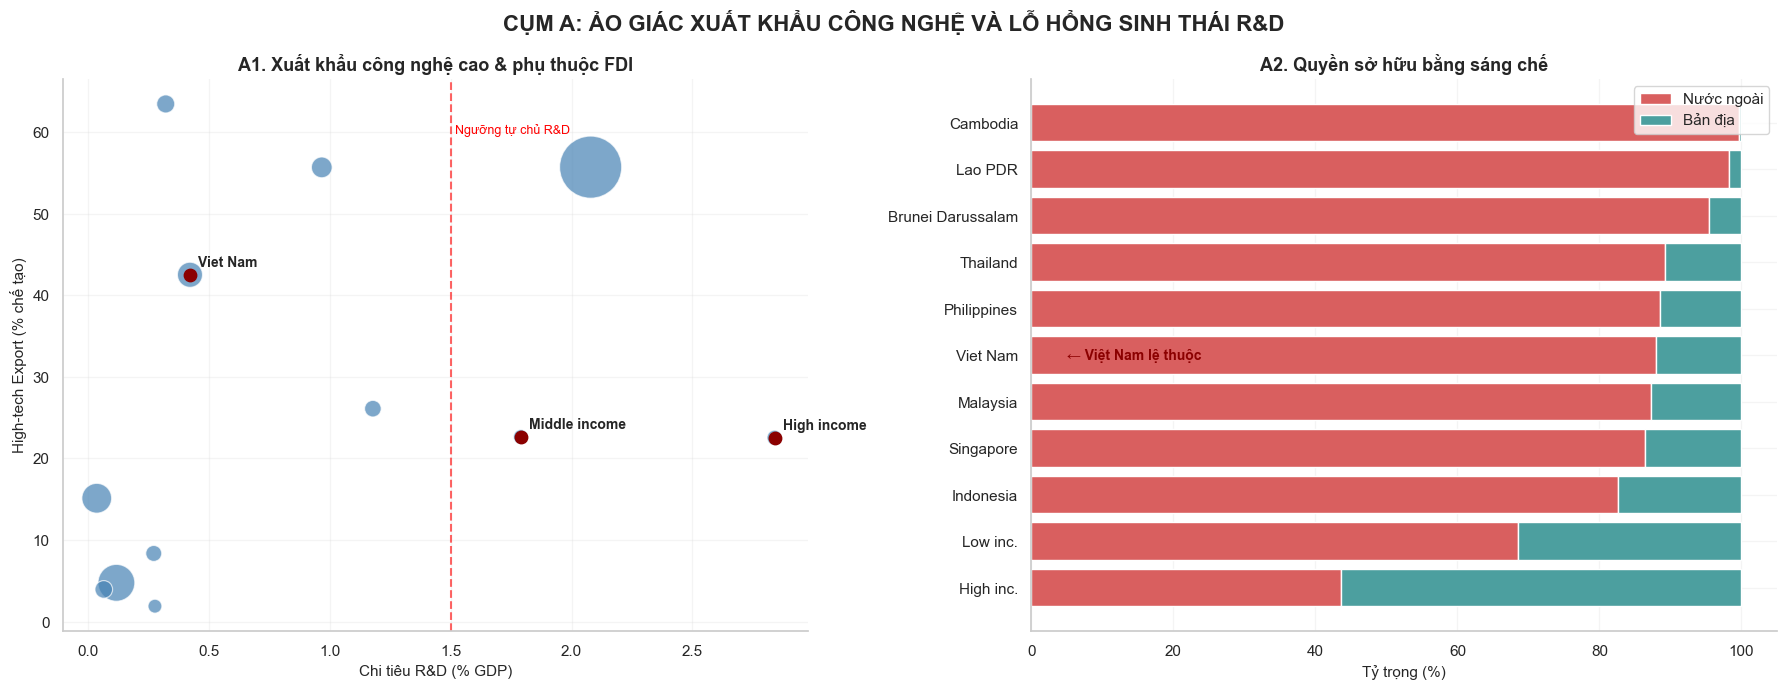

In [4]:
# ===================== PLOT: CLUSTER A =====================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('CỤM A: ẢO GIÁC XUẤT KHẨU CÔNG NGHỆ VÀ LỖ HỔNG SINH THÁI R&D',
             weight='bold', fontsize=16)

# ===================== A1: SCATTER =====================
df_a1 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['RnD', 'HighTech_Export', 'FDI_Inflows']]
    .mean()
    .reset_index()
    .dropna()
)

sns.scatterplot(
    data=df_a1,
    x='RnD',
    y='HighTech_Export',
    size='FDI_Inflows',
    sizes=(100, 2000),
    color='steelblue',
    alpha=0.7,
    legend=False,
    ax=axes[0]
)

highlight = ['Viet Nam', 'Low income', 'High income', 'Middle income']

for _, row in df_a1.iterrows():
    if row['Country Name'] in highlight:
        axes[0].scatter(row['RnD'], row['HighTech_Export'],
                        color='darkred', s=80, zorder=3)
        axes[0].annotate(
            row['Country Name'],
            (row['RnD'], row['HighTech_Export']),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            weight='bold'
        )

# Ngưỡng R&D
axes[0].axvline(1.5, color='red', linestyle='--', alpha=0.6)
axes[0].text(
    1.52,
    axes[0].get_ylim()[1] * 0.9,
    'Ngưỡng tự chủ R&D',
    color='red',
    fontsize=9
)

axes[0].set_title('A1. Xuất khẩu công nghệ cao & phụ thuộc FDI', weight='bold')
axes[0].set_xlabel('Chi tiêu R&D (% GDP)')
axes[0].set_ylabel('High-tech Export (% chế tạo)')


# ===================== A2: BAR =====================
df_a2 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['Patent_Resident', 'Patent_NonResident']]
    .mean()
    .reset_index()
    .dropna()
)

df_a2['Total'] = df_a2['Patent_Resident'] + df_a2['Patent_NonResident']
df_a2['Res_Pct'] = df_a2['Patent_Resident'] / df_a2['Total'] * 100
df_a2['NonRes_Pct'] = df_a2['Patent_NonResident'] / df_a2['Total'] * 100

df_a2 = df_a2.sort_values('NonRes_Pct')

# Rút gọn tên (nhưng vẫn readable)
df_a2['Short_Name'] = df_a2['Country Name'].str.replace('income', 'inc.', regex=False)

axes[1].barh(
    df_a2['Short_Name'],
    df_a2['NonRes_Pct'],
    color='#d95f5f',
    label='Nước ngoài'
)
axes[1].barh(
    df_a2['Short_Name'],
    df_a2['Res_Pct'],
    left=df_a2['NonRes_Pct'],
    color='#4c9f9f',
    label='Bản địa'
)

axes[1].set_title('A2. Quyền sở hữu bằng sáng chế', weight='bold')
axes[1].set_xlabel('Tỷ trọng (%)')


# Highlight Việt Nam (fix tên)
for i, name in enumerate(df_a2['Country Name']):
    if name == 'Viet Nam':
        axes[1].text(
            5, i,
            '← Việt Nam lệ thuộc',
            va='center',
            fontsize=10,
            weight='bold',
            color='darkred'
        )

axes[1].legend(loc='upper right')


# ===================== FINAL TOUCH =====================
for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)  # bỏ viền thừa cho sạch

plt.tight_layout()
plt.show()

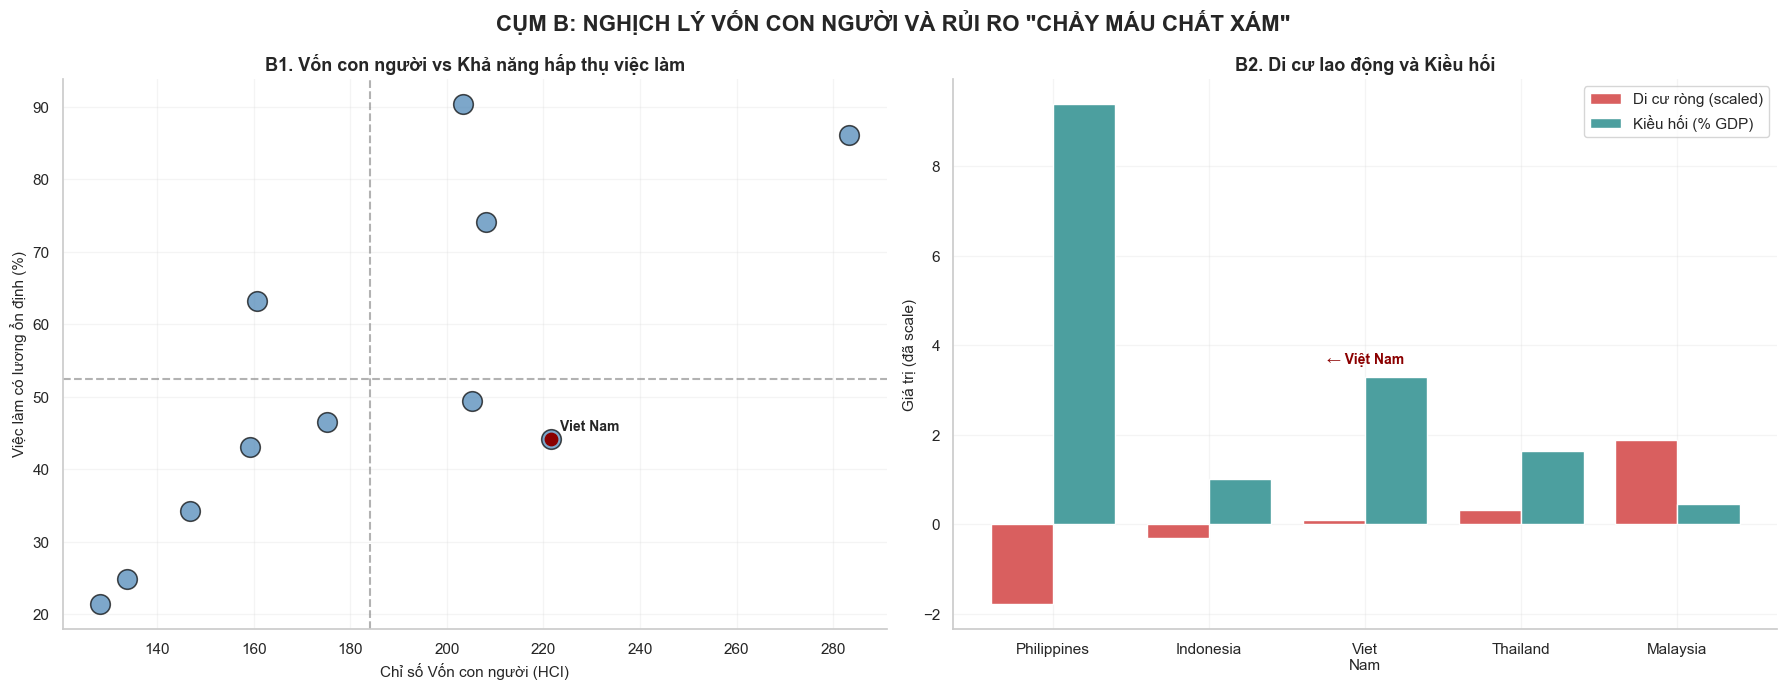

In [9]:
# ===================== PLOT: CLUSTER B =====================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('CỤM B: NGHỊCH LÝ VỐN CON NGƯỜI VÀ RỦI RO "CHẢY MÁU CHẤT XÁM"',
             weight='bold', fontsize=16)

# ===================== B1: SCATTER =====================
df_b1 = (
    df_multi[df_multi['Year'] == 2020]
    .dropna(subset=['HCI', 'Wage_Jobs'])
)

sns.scatterplot(
    data=df_b1,
    x='HCI',
    y='Wage_Jobs',
    color='steelblue',
    s=200,
    alpha=0.7,
    edgecolor='black',
    legend=False,
    ax=axes[0]
)

# Highlight giống style A
highlight = ['Viet Nam', 'Low income', 'High income', 'Middle income']

for _, row in df_b1.iterrows():
    if row['Country Name'] in highlight:
        axes[0].scatter(row['HCI'], row['Wage_Jobs'],
                        color='darkred', s=80, zorder=3)
        axes[0].annotate(
            row['Country Name'],
            (row['HCI'], row['Wage_Jobs']),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            weight='bold'
        )

# Mean lines (giữ nhưng clean)
axes[0].axvline(df_b1['HCI'].mean(), color='gray', linestyle='--', alpha=0.6)
axes[0].axhline(df_b1['Wage_Jobs'].mean(), color='gray', linestyle='--', alpha=0.6)

axes[0].set_title('B1. Vốn con người vs Khả năng hấp thụ việc làm', weight='bold')
axes[0].set_xlabel('Chỉ số Vốn con người (HCI)')
axes[0].set_ylabel('Việc làm có lương ổn định (%)')


# ===================== B2: BAR (FIX CLEAN) =====================
df_b2 = (
    df_multi[df_multi['Year'] >= 2015]
    .groupby('Country Name')[['Net_Migration', 'Remittances']]
    .mean()
    .reset_index()
    .dropna()
)

focus_mig = ['Philippines', 'Viet Nam', 'Indonesia', 'Thailand', 'Malaysia', 'Singapore']
df_b2 = df_b2[df_b2['Country Name'].isin(focus_mig)]

# Scale nhẹ (tránh bị dồn)
df_b2['Net_Migration_Scaled'] = df_b2['Net_Migration'] / 100000

# Sort cho đẹp
df_b2 = df_b2.sort_values('Net_Migration_Scaled')

# Rút gọn tên
df_b2['Short_Name'] = df_b2['Country Name'].str.replace(' ', '\n')

x = np.arange(len(df_b2))

axes[1].bar(
    x - 0.2,
    df_b2['Net_Migration_Scaled'],
    width=0.4,
    color='#d95f5f',
    label='Di cư ròng (scaled)'
)

axes[1].bar(
    x + 0.2,
    df_b2['Remittances'],
    width=0.4,
    color='#4c9f9f',
    label='Kiều hối (% GDP)'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(df_b2['Short_Name'])

axes[1].set_title('B2. Di cư lao động và Kiều hối', weight='bold')
axes[1].set_ylabel('Giá trị (đã scale)')

# Highlight Việt Nam
for i, name in enumerate(df_b2['Country Name']):
    if name == 'Viet Nam':
        axes[1].text(
            i,
            df_b2.iloc[i]['Remittances'] + 0.3,
            '← Việt Nam',
            ha='center',
            fontsize=10,
            weight='bold',
            color='darkred'
        )

axes[1].legend(loc='upper right')


# ===================== FINAL TOUCH =====================
for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

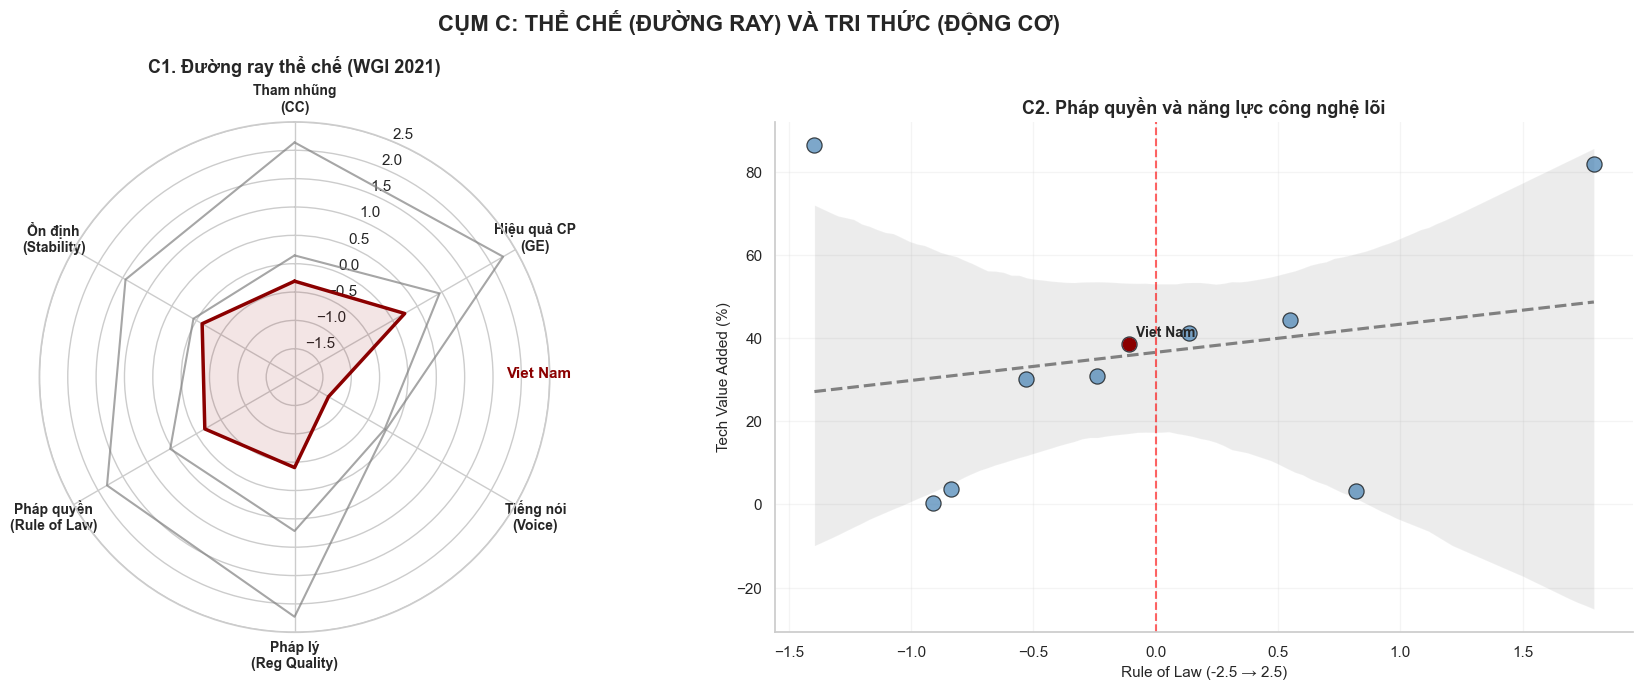

In [10]:
# ===================== PLOT: CLUSTER C =====================
fig = plt.figure(figsize=(18, 7))
fig.suptitle('CỤM C: THỂ CHẾ (ĐƯỜNG RAY) VÀ TRI THỨC (ĐỘNG CƠ)',
             weight='bold', fontsize=16)

# ===================== C1: RADAR =====================
ax_radar = fig.add_subplot(1, 2, 1, polar=True)

wgi_cols = ['WGI_CC', 'WGI_GE', 'WGI_VA', 'WGI_RQ', 'WGI_RL', 'WGI_PV']
wgi_labels = [
    'Tham nhũng\n(CC)', 'Hiệu quả CP\n(GE)', 'Tiếng nói\n(Voice)',
    'Pháp lý\n(Reg Quality)', 'Pháp quyền\n(Rule of Law)', 'Ổn định\n(Stability)'
]

df_c1 = df_multi[df_multi['Year'] == 2021].dropna(subset=wgi_cols)

# chỉ focus như các cluster trước
focus_rad = ['Viet Nam', 'Singapore', 'Malaysia', 'High income']

angles = np.linspace(0, 2*np.pi, len(wgi_cols), endpoint=False).tolist()
angles += angles[:1]

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(wgi_labels, fontsize=10, weight='bold')
ax_radar.set_ylim(-2, 2.5)

for c in focus_rad:
    if c in df_c1['Country Name'].values:
        vals = df_c1[df_c1['Country Name'] == c][wgi_cols].values.flatten().tolist()
        vals += vals[:1]

        # highlight Viet Nam giống style trước
        if c == 'Viet Nam':
            ax_radar.plot(angles, vals, color='darkred', linewidth=2.5)
            ax_radar.fill(angles, vals, color='darkred', alpha=0.1)
        else:
            ax_radar.plot(angles, vals, color='gray', linewidth=1.5, alpha=0.7)

ax_radar.set_title('C1. Đường ray thể chế (WGI 2021)', weight='bold', y=1.08)

# bỏ legend để sạch (giống A, B)
ax_radar.text(np.pi/2, 2.3, 'Viet Nam', color='darkred', ha='center', weight='bold')


# ===================== C2: SCATTER =====================
ax_scatter = fig.add_subplot(1, 2, 2)

df_c2 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['WGI_RL', 'Tech_ValueAdded']]
    .mean()
    .reset_index()
    .dropna()
)

# regression line nhẹ
sns.regplot(
    data=df_c2,
    x='WGI_RL',
    y='Tech_ValueAdded',
    scatter=False,
    color='gray',
    line_kws={"linestyle": "--"},
    ax=ax_scatter
)

# scatter clean (không hue)
sns.scatterplot(
    data=df_c2,
    x='WGI_RL',
    y='Tech_ValueAdded',
    color='steelblue',
    s=120,
    alpha=0.7,
    edgecolor='black',
    ax=ax_scatter
)

# highlight giống các cluster khác
highlight = ['Viet Nam', 'High income', 'Middle income', 'Low income']

for _, row in df_c2.iterrows():
    if row['Country Name'] in highlight:
        ax_scatter.scatter(row['WGI_RL'], row['Tech_ValueAdded'],
                           color='darkred', s=80, zorder=3)
        ax_scatter.annotate(
            row['Country Name'],
            (row['WGI_RL'], row['Tech_ValueAdded']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=10,
            weight='bold'
        )

# threshold line (giữ narrative)
ax_scatter.axvline(0, color='red', linestyle='--', alpha=0.6)

ax_scatter.set_title('C2. Pháp quyền và năng lực công nghệ lõi', weight='bold')
ax_scatter.set_xlabel('Rule of Law (-2.5 → 2.5)')
ax_scatter.set_ylabel('Tech Value Added (%)')


# ===================== FINAL TOUCH =====================
for ax in [ax_scatter]:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()